In [2]:
import pandas as pd
import networkx as nx

people = pd.read_csv("People.csv")
appearances = pd.read_csv("Appearances.csv")

# Filter to players since 1950
appearances = appearances[appearances["yearID"] >= 1950]

players_1950 = appearances["playerID"].unique()
people = people[people["playerID"].isin(players_1950)]

MLB_Network = nx.Graph()

# Add nodes
for player in appearances["playerID"].unique():
    MLB_Network.add_node(player)

# Create teammate edges
groups = appearances.groupby(["teamID", "yearID"])

for (team, year), group in groups:

    players = list(group["playerID"])

    for i in range(len(players)):
        for j in range(i + 1, len(players)):

            p1 = players[i]
            p2 = players[j]

            MLB_Network.add_edge(p1, p2)

# Check network size
print("Nodes:", MLB_Network.number_of_nodes())
print("Edges:", MLB_Network.number_of_edges())

# Get number of teammates for each player
degree_counts = dict(MLB_Network.degree())

# Find top 100 players with most teammates
top_players = sorted(degree_counts, key=degree_counts.get, reverse=True)[:100]

# Create subgraph with only those players
Top100_Network = MLB_Network.subgraph(top_players).copy()

# Add player names for Gephi
people["fullName"] = people["nameFirst"].fillna("") + " " + people["nameLast"].fillna("")
name_dict = dict(zip(people["playerID"], people["fullName"]))

nx.set_node_attributes(Top100_Network, name_dict, "label")

Nodes: 13475
Edges: 1194992


C:\Users\Mythi\AppData\Local\Temp\ipykernel_5792\1881365450.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20')


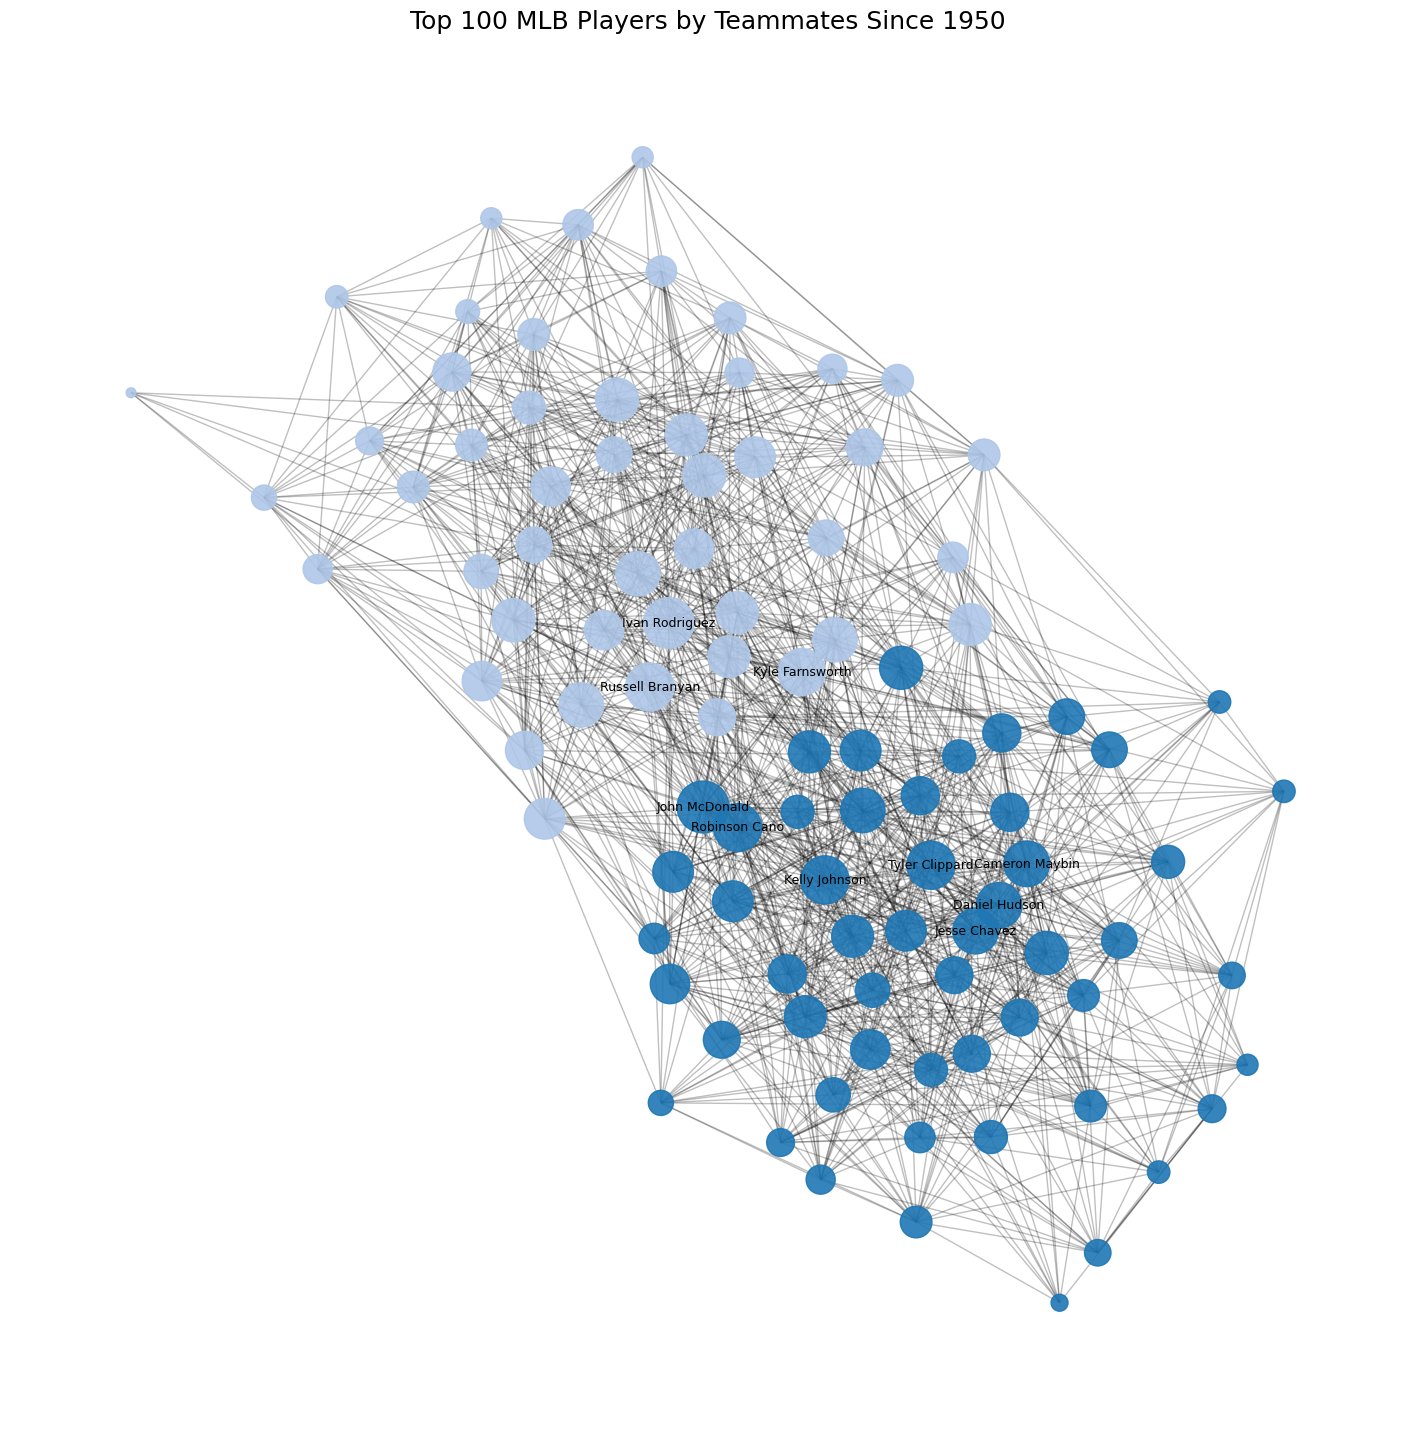

In [5]:
import matplotlib.pyplot as plt
import networkx as nx
from networkx.algorithms.community import greedy_modularity_communities
import matplotlib.cm as cm

# Compute layout
pos = nx.spring_layout(Top100_Network, seed=42, k=0.5, iterations=200)

# Compute communities
communities = list(greedy_modularity_communities(Top100_Network))

cmap = cm.get_cmap('tab20')
color_map = {}
for i, community in enumerate(communities):
    for node in community:
        color_map[node] = cmap(i % 20)

node_colors = [color_map[n] for n in Top100_Network.nodes()]

degrees = dict(Top100_Network.degree())

node_sizes = [
    (degrees[n] ** 1.8) * 2   # exponent makes high-degree nodes MUCH larger
    for n in Top100_Network.nodes()
]

plt.figure(figsize=(18, 18))

nx.draw_networkx_nodes(
    Top100_Network,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    alpha=0.9
)

nx.draw_networkx_edges(
    Top100_Network,
    pos,
    width=1,
    alpha=0.25
)

# Label top 10
top_10= sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:10]
top_labels = {n: Top100_Network.nodes[n]['label'] for n, _ in top_10}

nx.draw_networkx_labels(
    Top100_Network,
    pos,
    labels=top_labels,
    font_size=9
)

plt.axis('off')
plt.title("Top 100 MLB Players by Teammates Since 1950", fontsize=18)
plt.show()